Notebook 4: Evaluation of all repair methods

This notebook scores the stored repairs of six methods and compares them:

- **dictionary lookup**: each damaged word becomes the closest entry of a word list built from the excerpts
  outside the sample (edit distance, ties by frequency). No context, no model (notebook 2b).
- **BERT, no dictionary**: `bert-base-cased` fine-tuned on clean text, filling the slots left to right with a
  letter-similarity reranking of its own candidates (notebook 2). An ablation line: it shows what the
  dictionary candidates add.
- **BERT + dictionary**: the same model and reranking, with the 5 closest word-list entries of each damaged
  word added to BERT's candidates (notebook 2b). The main encoder method.
- **few-shot**: Qwen3 30B A3B Instruct with the instruction, 5 solved examples and the sentence with numbered
  slots (notebook 3).
- **few-shot + article**: the same with the whole article as context (notebook 3). Only compared with the
  LLM's own few-shot result: the other methods see the sentence only.
- **BART**: `facebook/bart-base` fine-tuned as a denoiser on damaged text from the same damage generator
  (notebook 2c). The only method trained on damaged text, so likely an optimistic estimate.

All methods get the same sentence (slot view) and are scored on exactly the same rows. The damaged text
itself ("no repair") is scored the same way as a reference.

**Input.** `data/processed/corrupted_v2.jsonl` (hash checked), the stored predictions in `runs/preds/`
(nothing is sent to a model here), `configs/llm.yaml`, `configs/bert_repair.yaml`,
`configs/bert_repair_lex.yaml`, `configs/lexicon.yaml` and `configs/bart_repair.yaml` for the version names.

**Output.** The tables and the figure below.

`SPLIT` chooses the rows. It is `test` here: this is the one run on the test split, and its numbers are the
results of the study. All methods, settings and scores were fixed on dev before this run, and the notebook is
not run on test again. A method is scored only when all of its rows for the split are stored.

In [1]:
import hashlib
import json
import time

import pandas as pd
import transformers
from bert_score import BERTScorer

from blnrepair.data import ROOT, load_config
from blnrepair.evaluation import ci_long, paired_tests, resample_index, row_scores, wrong_fact_rate
from blnrepair.freeze import load_frozen
from blnrepair.bart_data import bart_version, load_bart_repair_config
from blnrepair.bert_repair import load_repair_config, repair_version
from blnrepair.lexicon import lexicon_version, load_lexicon_config
from blnrepair.llm import load_llm_config, variant_versions
from blnrepair.plots import level_lines
from blnrepair.preds import load_preds, pred_path

transformers.logging.set_verbosity_error()
pd.set_option("display.max_colwidth", None)
config, llm_config = load_config(), load_llm_config()
rows = load_frozen("v2")  # stops if the file hash does not match runs/corrupted_v2.sha256
by_key = {(r["id"], r["severity"]): r for r in rows}
LEVELS = ["1w", "10", "25", "50", "75"]
SPLIT = "test"

/Users/simonm/UniRGB_local/GenAI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


What is scored

The rows are every row of the split that has slots (level 0 is the clean sentence), without the 5
sentences shown as few-shot examples: their gold answers are in the prompt. On the test split this leaves
nothing out, because the examples are dev sentences and dev and test share no excerpt. Below, how many rows
each method has stored.

In [2]:
example_ids = {i for i, _ in llm_config["fewshot_picks"]}
scored_rows = [r for r in rows if r["split"] == SPLIT and r["id"] not in example_ids and r["k"]]
scored_ids = sorted({r["id"] for r in scored_rows})
expected = {(r["id"], r["severity"]) for r in scored_rows}

versions = variant_versions(llm_config, SPLIT)
VARIANTS = {  # fixed order: a method keeps its colour in every figure
    "BERT + dictionary": ("bert_rerank", repair_version(load_repair_config(ROOT / "configs" / "bert_repair_lex.yaml"), SPLIT)),
    "few-shot": versions["few-shot"],
    "few-shot + article": versions["few-shot + article"],
    "dictionary lookup": ("lexicon", lexicon_version(load_lexicon_config(), SPLIT)),
    "BERT, no dictionary": ("bert_rerank", repair_version(load_repair_config(), SPLIT)),
    "BART": ("bart", bart_version(load_bart_repair_config(), SPLIT)),
}
ORDER = list(VARIANTS)
FORMAT = ["few-shot", "few-shot + article", "BART"]  # methods whose answer can be unreadable
stored = {name: {(p["id"], p["severity"]): p for p in load_preds(pred_path(*v))} for name, v in VARIANTS.items()}
available = [name for name in VARIANTS if expected <= set(stored[name])]
METHODS = available + ["no repair"]
print(f"{len(scored_ids)} sentences, {len(expected)} rows per method in the {SPLIT} split")
pd.DataFrame({"version": {n: f"{m}_{v}" for n, (m, v) in VARIANTS.items()},
              "rows stored": {n: len(expected & set(s)) for n, s in stored.items()},
              "rows needed": len(expected), "scored": {n: n in available for n in stored}})

150 sentences, 750 rows per method in the test split


,version,rows stored,rows needed,scored
BERT + dictionary,bert_rerank_ftv1-l64-b5-n10-x5-test,750,750,True
few-shot,llm_fewshot_v4-qwen3-30b-a3b-instruct-2507-exb46768-test,750,750,True
few-shot + article,llm_fewshot_article_v3-qwen3-30b-a3b-instruct-2507-exb46768-test,750,750,True
dictionary lookup,lexicon_v1-test,750,750,True
"BERT, no dictionary",bert_rerank_ftv1-l8-b5-n10-test,750,750,True
BART,bart_ftv1-greedy-test,750,750,True


The scores

All scores are per sentence and level, over the damaged span unless stated (dossier §8). Primary:

- **BERTScore of the span**: F1 between the repaired span and the gold span, with `roberta-large` and the
  package's baseline rescaling (so unrelated text scores near 0 and identical text 1).
- **Fact Recovery Rate**: share of the span's fact tokens restored exactly in their slot (punctuation around
  the word ignored), averaged over sentences.
- **Anchor recovery**: whether the anchor fact is restored. The anchor is the same word at every level and is
  never dropped, so this is the cleanest series across levels (the share of facts among the damaged words
  falls as the span grows).

Secondary: Fact Recovery split into **visible** fact slots (some letters left) and **dropped** fact slots
(only context left), pooled over slots, because many sentences have no dropped fact; **exact words**;
**CER** of the span before and after repair and the **repair gain** (before minus after), all pooled per
level (all character edits over all gold characters), because on a one-word span a single wrong word can
give a sentence CER above 1, so a mean per sentence would be driven by the shortest spans; and **BERTScore
of the sentence**.

A format failure (the LLM answered with the wrong number of words) is scored as **no repair**: its slots
count as wrong, and its text is the damaged text. The LLM is also shown over its valid answers only.

In [3]:
def multiword_count(p):
    # LLM rows keep a dict with the positions of multi-word answers; BERT and lookup rows keep a list,
    # BART rows a dict without them
    raw = json.loads(p["raw_output"]) if isinstance(p["raw_output"], str) else p["raw_output"]
    return len(raw.get("multiword", [])) if isinstance(raw, dict) else 0


records = []
for name in available:
    for key in sorted(expected):
        p, row = stored[name][key], by_key[key]
        records.append({"method": name, "id": key[0], "level": key[1], "band": row["band"],
                        "multiword": multiword_count(p), **row_scores(row, p["pred_words"])})
for key in sorted(expected):
    records.append({"method": "no repair", "id": key[0], "level": key[1], "band": by_key[key]["band"],
                    "multiword": 0, **row_scores(by_key[key], None), "format_ok": True})
scores = pd.DataFrame(records)
scores["repair gain"] = scores["CER before"] - scores["CER after"]
scores["format failure"] = ~scores["format_ok"]

In [4]:
scorer = BERTScorer(model_type="roberta-large", lang="en", rescale_with_baseline=True)
t0 = time.perf_counter()
scores["BERTScore span"] = scorer.score(list(scores["repaired span"]), list(scores["gold span"]))[2].numpy()
gold_sentence = {r["id"]: r["gold_text"] for r in scored_rows}
scores["BERTScore sentence"] = scorer.score(list(scores["repaired sentence"]), [gold_sentence[i] for i in scores["id"]])[2].numpy()
print(f"BERTScore for {len(scores)} spans and sentences in {time.perf_counter() - t0:.0f} s")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 8368.47it/s]

/Users/simonm/UniRGB_local/GenAI/.venv/lib/python3.11/site-packages/bert_score/scorer.py:139: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self._baseline_vals = torch.from_numpy(


BERTScore for 5250 spans and sentences in 637 s


Results with 95% confidence intervals

Every cell is the estimate with a 95% bootstrap interval. The sentence is the unit that is resampled
(10,000 resamples, percentile interval): the slots of one sentence share its context and are filled one after
another, so resampling single slots would treat them as independent and make the intervals too narrow.
Every method and level uses the same resampled sentence sets, and pooled rates are recomputed in every
resample.

In [5]:
N_BOOT = 10_000
index = resample_index(len(scored_ids), N_BOOT, seed=config["seed"])
ci = ci_long(scores, ["BERTScore span", "Fact Recovery Rate", "anchor recovery", "visible fact slots",
                      "dropped fact slots", "exact words", "CER before (pooled)", "CER after (pooled)",
                      "repair gain (pooled)", "BERTScore sentence"], scored_ids, index)
fmt = lambda r: "n/a" if pd.isna(r["value"]) else f"{r['value']:.2f} [{r['low']:.2f}, {r['high']:.2f}]"
ci["cell"] = ci.apply(fmt, axis=1)


def ci_table(metric, methods=METHODS):
    return ci[ci["metric"] == metric].pivot(index="level", columns="method", values="cell").reindex(index=LEVELS, columns=methods)


for metric in ["BERTScore span", "Fact Recovery Rate", "anchor recovery"]:
    print(metric)
    display(ci_table(metric))

BERTScore span


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",BART,no repair
level,,,,,,,
1w,"0.77 [0.71, 0.82]","0.74 [0.69, 0.78]","0.83 [0.79, 0.88]","0.72 [0.66, 0.77]","0.48 [0.42, 0.53]","0.70 [0.64, 0.75]","0.30 [0.26, 0.34]"
10,"0.62 [0.57, 0.67]","0.60 [0.55, 0.65]","0.69 [0.64, 0.74]","0.52 [0.47, 0.56]","0.36 [0.31, 0.41]","0.67 [0.62, 0.71]","0.01 [-0.02, 0.04]"
25,"0.47 [0.43, 0.51]","0.46 [0.43, 0.49]","0.56 [0.52, 0.59]","0.41 [0.38, 0.45]","0.16 [0.12, 0.19]","0.62 [0.58, 0.67]","-0.16 [-0.18, -0.13]"
50,"0.42 [0.39, 0.45]","0.24 [0.18, 0.30]","0.40 [0.34, 0.45]","0.37 [0.34, 0.40]","0.02 [-0.00, 0.05]","0.56 [0.50, 0.61]","-0.26 [-0.28, -0.25]"
75,"0.40 [0.37, 0.43]","0.07 [0.00, 0.13]","0.13 [0.06, 0.21]","0.37 [0.34, 0.40]","-0.02 [-0.05, 0.00]","0.50 [0.44, 0.56]","-0.31 [-0.33, -0.30]"


Fact Recovery Rate


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",BART,no repair
level,,,,,,,
1w,"0.58 [0.50, 0.66]","0.49 [0.41, 0.57]","0.69 [0.61, 0.76]","0.51 [0.43, 0.59]","0.25 [0.18, 0.32]","0.47 [0.39, 0.55]","0.00 [0.00, 0.00]"
10,"0.54 [0.47, 0.61]","0.46 [0.39, 0.54]","0.58 [0.51, 0.65]","0.49 [0.42, 0.56]","0.13 [0.09, 0.18]","0.45 [0.38, 0.51]","0.00 [0.00, 0.00]"
25,"0.49 [0.43, 0.56]","0.38 [0.32, 0.44]","0.57 [0.50, 0.63]","0.46 [0.40, 0.52]","0.08 [0.05, 0.11]","0.42 [0.36, 0.48]","0.00 [0.00, 0.00]"
50,"0.48 [0.42, 0.53]","0.32 [0.26, 0.38]","0.46 [0.40, 0.53]","0.47 [0.42, 0.53]","0.05 [0.03, 0.07]","0.42 [0.36, 0.48]","0.00 [0.00, 0.00]"
75,"0.48 [0.43, 0.53]","0.22 [0.17, 0.27]","0.32 [0.26, 0.38]","0.43 [0.39, 0.48]","0.04 [0.02, 0.07]","0.40 [0.34, 0.45]","0.00 [0.00, 0.00]"


anchor recovery


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",BART,no repair
level,,,,,,,
1w,"0.58 [0.50, 0.66]","0.49 [0.41, 0.57]","0.69 [0.61, 0.76]","0.51 [0.43, 0.59]","0.25 [0.18, 0.32]","0.47 [0.39, 0.55]","0.00 [0.00, 0.00]"
10,"0.55 [0.47, 0.63]","0.48 [0.40, 0.56]","0.59 [0.51, 0.67]","0.51 [0.43, 0.59]","0.13 [0.07, 0.18]","0.43 [0.35, 0.51]","0.00 [0.00, 0.00]"
25,"0.54 [0.46, 0.62]","0.43 [0.35, 0.51]","0.59 [0.51, 0.67]","0.51 [0.43, 0.59]","0.07 [0.03, 0.12]","0.42 [0.34, 0.50]","0.00 [0.00, 0.00]"
50,"0.53 [0.45, 0.61]","0.36 [0.29, 0.44]","0.49 [0.41, 0.57]","0.51 [0.43, 0.59]","0.05 [0.02, 0.09]","0.39 [0.31, 0.47]","0.00 [0.00, 0.00]"
75,"0.53 [0.45, 0.61]","0.25 [0.18, 0.32]","0.35 [0.28, 0.43]","0.51 [0.43, 0.59]","0.03 [0.01, 0.07]","0.36 [0.29, 0.44]","0.00 [0.00, 0.00]"


Secondary scores, same layout. "CER before" is the same for every method (it is the damaged text), so it is
shown once, in the "no repair" column.

In [6]:
print("fact slots per level (the same for every method)")
display(scores[scores["method"] == "no repair"].groupby("level")[["visible facts", "dropped facts"]].sum().reindex(LEVELS).T)
for metric in ["visible fact slots", "dropped fact slots", "exact words", "CER after (pooled)", "repair gain (pooled)",
               "BERTScore sentence"]:
    print(metric)
    display(ci_table(metric, available if metric in ["repair gain (pooled)"] else METHODS))
print("CER before (pooled)")
display(ci_table("CER before (pooled)", ["no repair"]))

fact slots per level (the same for every method)


level,1w,10,25,50,75
visible facts,150,228,306,433,562
dropped facts,0,13,28,43,62


visible fact slots


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",BART,no repair
level,,,,,,,
1w,"0.58 [0.50, 0.66]","0.49 [0.41, 0.57]","0.69 [0.61, 0.76]","0.51 [0.43, 0.59]","0.25 [0.18, 0.32]","0.47 [0.39, 0.55]","0.00 [0.00, 0.00]"
10,"0.57 [0.51, 0.64]","0.48 [0.41, 0.55]","0.61 [0.54, 0.68]","0.51 [0.44, 0.58]","0.14 [0.10, 0.19]","0.49 [0.43, 0.55]","0.00 [0.00, 0.00]"
25,"0.52 [0.46, 0.59]","0.42 [0.36, 0.48]","0.58 [0.51, 0.65]","0.49 [0.43, 0.56]","0.10 [0.07, 0.15]","0.47 [0.41, 0.53]","0.00 [0.00, 0.00]"
50,"0.52 [0.47, 0.57]","0.30 [0.24, 0.37]","0.46 [0.38, 0.53]","0.50 [0.45, 0.55]","0.06 [0.04, 0.09]","0.48 [0.42, 0.53]","0.00 [0.00, 0.00]"
75,"0.53 [0.48, 0.58]","0.22 [0.17, 0.28]","0.28 [0.22, 0.35]","0.48 [0.44, 0.53]","0.06 [0.04, 0.08]","0.47 [0.41, 0.52]","0.00 [0.00, 0.00]"


dropped fact slots


...

method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",BART
level,,,,,,
1w,"0.11 [0.08, 0.14]","0.02 [-0.03, 0.07]","0.10 [0.06, 0.15]","0.07 [0.03, 0.11]","-0.30 [-0.36, -0.24]","-0.08 [-0.14, -0.01]"
10,"0.15 [0.13, 0.16]","0.08 [0.05, 0.11]","0.11 [0.08, 0.13]","0.09 [0.07, 0.11]","-0.18 [-0.22, -0.14]","0.05 [0.02, 0.09]"
25,"0.14 [0.12, 0.15]","0.08 [0.06, 0.09]","0.09 [0.07, 0.11]","0.10 [0.08, 0.11]","-0.25 [-0.28, -0.22]","0.10 [0.08, 0.12]"
50,"0.13 [0.12, 0.14]","0.06 [0.05, 0.08]","0.08 [0.07, 0.10]","0.10 [0.09, 0.11]","-0.32 [-0.34, -0.30]","0.10 [0.08, 0.12]"
75,"0.14 [0.13, 0.14]","0.05 [0.04, 0.06]","0.05 [0.04, 0.06]","0.10 [0.10, 0.11]","-0.34 [-0.36, -0.32]","0.10 [0.08, 0.11]"


BERTScore sentence


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",BART,no repair
level,,,,,,,
1w,"0.98 [0.97, 0.98]","0.97 [0.97, 0.98]","0.98 [0.98, 0.99]","0.97 [0.96, 0.97]","0.94 [0.93, 0.95]","0.97 [0.96, 0.98]","0.91 [0.90, 0.92]"
10,"0.93 [0.92, 0.94]","0.92 [0.91, 0.93]","0.94 [0.94, 0.95]","0.90 [0.89, 0.91]","0.87 [0.86, 0.88]","0.94 [0.93, 0.95]","0.78 [0.77, 0.79]"
25,"0.81 [0.80, 0.83]","0.81 [0.80, 0.83]","0.84 [0.83, 0.86]","0.80 [0.78, 0.81]","0.68 [0.66, 0.69]","0.87 [0.86, 0.89]","0.53 [0.52, 0.54]"
50,"0.66 [0.64, 0.68]","0.54 [0.50, 0.58]","0.64 [0.61, 0.68]","0.65 [0.63, 0.66]","0.40 [0.38, 0.42]","0.74 [0.71, 0.77]","0.20 [0.19, 0.22]"
75,"0.53 [0.50, 0.55]","0.25 [0.20, 0.30]","0.30 [0.24, 0.36]","0.51 [0.49, 0.53]","0.17 [0.15, 0.19]","0.61 [0.56, 0.65]","-0.07 [-0.08, -0.06]"


CER before (pooled)


method,no repair
level,
1w,"0.25 [0.24, 0.26]"
10,"0.30 [0.28, 0.32]"
25,"0.31 [0.29, 0.32]"
50,"0.31 [0.30, 0.32]"
75,"0.31 [0.30, 0.32]"


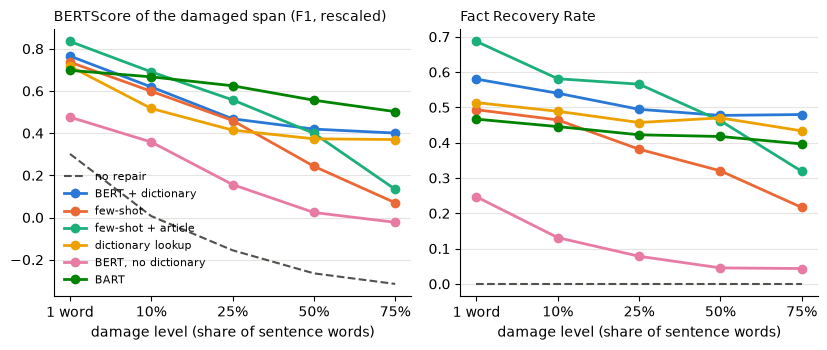

In [7]:
means = ci[ci["metric"].isin(["BERTScore span", "Fact Recovery Rate"])].pivot_table(
    index=["method", "level"], columns="metric", values="value").reindex(pd.MultiIndex.from_product([METHODS, LEVELS]))
fig = level_lines(means, ["BERTScore span", "Fact Recovery Rate"],
                  ["BERTScore of the damaged span (F1, rescaled)", "Fact Recovery Rate"], ORDER)

Format failures and scores over valid answers only

Format failures per level (a format failure is scored as no repair) for the methods that write free text (the
LLM and BART), and their scores over the rows with a valid answer only. The valid-only scores show whether a
difference to the other methods comes from better or worse repairs or only from the answers that could not
be read.

In [8]:
llm_scored = [m for m in FORMAT if m in available]
failures = scores[scores["method"].isin(llm_scored)].pivot_table(index="level", columns="method", values="format failure",
                                                                 aggfunc="sum").reindex(index=LEVELS, columns=llm_scored)
failures.loc["all"] = failures.sum()
print(f"format failures per level (of {len(scored_ids)} sentences per level); multi-word answers: "
      f"{scores.groupby('method')['multiword'].sum().reindex(llm_scored).to_dict()}")
display(failures)
valid = scores[scores["method"].isin(llm_scored) & scores["format_ok"]]
valid.groupby(["level", "method"])[["BERTScore span", "fact recovery", "anchor ok"]].agg(["mean", "size"]) \
    .reindex(pd.MultiIndex.from_product([LEVELS, llm_scored])).round(3)

format failures per level (of 150 sentences per level); multi-word answers: {'few-shot': 11, 'few-shot + article': 10, 'BART': 0}


method,few-shot,few-shot + article,BART
level,,,
1w,1,0,0
10,0,0,0
25,2,2,6
50,37,23,13
75,66,68,21
all,106,93,40


BERTScore span      fact recovery      anchor ok     
                                mean size          mean size      mean size
1w few-shot                    0.739  149         0.497  149     0.497  149
   few-shot + article          0.835  150         0.687  150     0.687  150
   BART                        0.698  150         0.467  150     0.467  150
10 few-shot                    0.598  150         0.464  150     0.480  150
   few-shot + article          0.690  150         0.581  150     0.593  150
   BART                        0.667  150         0.446  150     0.433  150
25 few-shot                    0.470  148         0.387  148     0.439  148
   few-shot + article          0.567  148         0.573  148     0.595  148
   BART                        0.660  144         0.440  144     0.438  144
50 few-shot                    0.428  113         0.425  113     0.478  113
   few-shot + article          0.530  127         0.546  127     0.575  127
   BART                        0.637  137         0.457  137     0.431  137
75 few-shot                    0.398   84         0.387   84     0.440   84
   few-shot + article          0.532   82         0.583   82     0.646   82
   BART                        0.639  129         0.461  129     0.419  129

Paired tests

Every sentence is repaired at every level by every method, so methods are compared sentence by sentence.
Only two comparisons are tested, each for a hypothesis stated before the test run; all other comparisons are
shown descriptively below, with the intervals above:

- **BERT + dictionary against few-shot** (H2, SQ2): the best encoder method against the LLM, with the same
  input.
- **few-shot against dictionary lookup** (H2b): does the GenAI method beat a plain dictionary lookup? The
  LLM is used here, not BERT + dictionary, because BERT + dictionary contains the lookup itself.

Per level, **McNemar's exact test** on anchor recovery (a yes or no per sentence, paired: only sentences
where exactly one method restores the anchor count) and the **Wilcoxon signed-rank test** on span BERTScore
(paired, bounded and skewed scores, so no normality is assumed; sentences with equal scores are left out).
The p-values of each test are **Holm-adjusted** over the 2 pairs and 5 levels together (10 tests per family),
which controls the chance of any false positive without assuming the tests are independent.

In [9]:
PAIRS = [("BERT + dictionary", "few-shot"), ("few-shot", "dictionary lookup")]
if all(m in available for pair in PAIRS for m in pair):
    tests = paired_tests(scores, PAIRS, LEVELS, scored_ids)
    display(tests.round(4))
else:
    print("paired tests: not all methods have a complete run")

,first,second,level,anchor: first only,anchor: second only,McNemar p,BERTScore: first higher,BERTScore: second higher,Wilcoxon p,McNemar p (Holm),Wilcoxon p (Holm)
0,BERT + dictionary,few-shot,1w,26,13,0.0533,44,37,0.2028,0.2663,0.8112
1,BERT + dictionary,few-shot,10,27,16,0.1263,65,65,0.5636,0.4456,1.0000
2,BERT + dictionary,few-shot,25,30,14,0.0226,77,73,0.8637,0.1358,1.0000
3,BERT + dictionary,few-shot,50,39,14,0.0008,85,65,0.0000,0.0064,0.0004
4,BERT + dictionary,few-shot,75,55,13,0.0000,101,49,0.0000,0.0000,0.0000
5,few-shot,dictionary lookup,1w,18,21,0.7493,48,38,0.5142,1.0000,1.0000
6,few-shot,dictionary lookup,10,20,25,0.5515,81,59,0.0055,1.0000,0.0387
7,few-shot,dictionary lookup,25,18,30,0.1114,90,60,0.0139,0.4456,0.0693
8,few-shot,dictionary lookup,50,13,36,0.0014,72,78,0.0064,0.0098,0.0387
9,few-shot,dictionary lookup,75,13,53,0.0000,49,101,0.0000,0.0000,0.0000


**Descriptive paired comparisons.** The mean difference (first minus second) and how many sentences were
better, equal or worse. **BERT + dictionary against dictionary lookup** shows what BERT's context adds to the
letters; **BERT + dictionary against BERT, no dictionary** what the dictionary candidates add; **few-shot +
article against few-shot** whether the article helps the LLM; **BART against few-shot** and **against BERT +
dictionary** place the supervised denoiser (added after the hypotheses were written, so descriptive only).

In [10]:
def paired(a, b, metric):
    wide = scores[scores["method"].isin([a, b])].pivot_table(index=["level", "id"], columns="method", values=metric)
    diff = (wide[a] - wide[b]).rename("diff").reset_index()
    return diff.groupby("level").agg(mean_diff=("diff", "mean"), better=("diff", lambda d: (d > 1e-9).sum()),
                                     same=("diff", lambda d: (d.abs() <= 1e-9).sum()),
                                     worse=("diff", lambda d: (d < -1e-9).sum())).reindex(LEVELS)


for a, b in [("BERT + dictionary", "dictionary lookup"), ("BERT + dictionary", "BERT, no dictionary"),
             ("few-shot + article", "few-shot"), ("BART", "few-shot"), ("BART", "BERT + dictionary")]:
    if {a, b} <= set(available):
        print(f"{a} against {b}")
        display(pd.concat({m: paired(a, b, m) for m in ["BERTScore span", "fact recovery"]}, axis=1).round(3))

BERT + dictionary against dictionary lookup


BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w             0.048     41   91    18         0.067     18  124     8
10             0.102     87   32    31         0.051     23  119     8
25             0.054     90    7    53         0.037     22  114    14
50             0.046     87    0    63         0.007     27  102    21
75             0.031     89    0    61         0.046     40   93    17

BERT + dictionary against BERT, no dictionary


BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w             0.289     98   38    14         0.333     53   94     3
10             0.261    119    4    27         0.409     80   68     2
25             0.312    134    1    15         0.416     94   55     1
50             0.395    148    0     2         0.432    111   35     4
75             0.423    147    0     3         0.436    125   24     1

few-shot + article against few-shot


BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w             0.098     44   92    14         0.193     35  109     6
10             0.092     73   47    30         0.117     36  106     8
25             0.098     99    8    43         0.184     56   81    13
50             0.156     97   20    33         0.142     52   82    16
75             0.064     71   47    32         0.102     45   83    22

BART against few-shot


BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w            -0.039     43   55    52        -0.027     19  108    23
10             0.068     79   19    52        -0.019     33   84    33
25             0.165    114    1    35         0.041     45   74    31
50             0.313    117    3    30         0.097     60   55    35
75             0.432    119   10    21         0.180     72   55    23

BART against BERT + dictionary


BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w            -0.068     33   64    53        -0.113     10  113    27
10             0.048     68   19    63        -0.094     19   94    37
25             0.157    112    2    36        -0.072     33   75    42
50             0.137    117    0    33        -0.060     34   73    43
75             0.102    114    0    36        -0.083     33   66    51

Does span BERTScore see the fact? (SQ3)

For each method and level: the chance that a repair with the **wrong** anchor gets at least as high a span
BERTScore as a repair with the **right** anchor (all pairs of one such repair each; equal scores count
half). 0 means BERTScore always ranks the right fact higher; 0.5 means BERTScore does not see the fact at
all. This is 1 minus the AUC of BERTScore as a detector of a correct anchor. It needs no threshold, so
there is nothing to choose on dev: the two reference points are fixed. It is computed per method, because
pooling methods would mix the difference between methods into it. At the one-word level the span is the
anchor alone, so the value must be near 0 there (a check of the code). "n/a" means that the method got the
anchor right in every sentence or in none.

In [11]:
repaired = scores[scores["method"].isin(available)]
sq3 = repaired.groupby(["level", "method"]).apply(
    lambda g: pd.Series({"wrong-fact rate": wrong_fact_rate(g["BERTScore span"], g["anchor ok"]),
                         "anchor wrong": int((~g["anchor ok"]).sum())}), include_groups=False)
sq3["wrong-fact rate"].unstack("method").reindex(index=LEVELS, columns=available).round(2)

method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",BART
level,,,,,,
1w,0.00,0.00,0.00,0.00,0.00,0.00
10,0.25,0.19,0.12,0.22,0.10,0.11
25,0.33,0.34,0.33,0.32,0.20,0.25
50,0.37,0.24,0.23,0.36,0.19,0.28
75,0.45,0.18,0.10,0.43,0.15,0.28


By level and length band (BERTScore of the span, mean): separates the share of damaged words from the
absolute length of the damaged span.

In [12]:
scores.pivot_table(index="level", columns=["band", "method"], values="BERTScore span", aggfunc="mean") \
      .reindex(index=LEVELS).round(2)

band   20-29                                                                   \
method  BART BERT + dictionary BERT, no dictionary dictionary lookup few-shot   
level                                                                           
1w      0.68              0.72                0.43              0.69     0.72   
10      0.65              0.61                0.40              0.52     0.59   
25      0.60              0.47                0.16              0.42     0.46   
50      0.56              0.41                0.07              0.38     0.35   
75      0.53              0.40                0.03              0.38     0.26   

band                                30-44                    \
method few-shot + article no repair  BART BERT + dictionary   
level                                                         
1w                   0.83      0.33  0.69              0.81   
10                   0.68      0.10  0.67              0.64   
25                   0.56     -0.09  0.65              0.49   
50                   0.49     -0.20  0.54              0.43   
75                   0.40     -0.25  0.48              0.39   

band                        ...                                       45-60  \
method BERT, no dictionary  ... few-shot few-shot + article no repair  BART   
level                       ...                                               
1w                    0.50  ...     0.74               0.83      0.26  0.76   
10                    0.33  ...     0.62               0.73     -0.03  0.72   
25                    0.18  ...     0.49               0.59     -0.18  0.63   
50                   -0.01  ...     0.30               0.43     -0.29  0.57   
75                   -0.04  ...    -0.02               0.02     -0.35  0.48   

band                                                                     \
method BERT + dictionary BERT, no dictionary dictionary lookup few-shot   
level                                                                     
1w                  0.77                0.53              0.78     0.76   
10                  0.61                0.31              0.49     0.56   
25                  0.42                0.10              0.41     0.38   
50                  0.41               -0.03              0.36    -0.14   
75                  0.43               -0.11              0.39    -0.20   

band                                 
method few-shot + article no repair  
level                                
1w                   0.86      0.33  
10                   0.62     -0.14  
25                   0.48     -0.27  
50                   0.08     -0.36  
75                  -0.25     -0.39  

[5 rows x 21 columns]

**Contamination probe.** The share of near-verbatim continuations of the LLM's probe (notebook 3): a high
share would mean the LLM results may be inflated.

In [13]:
probe = pd.DataFrame([json.loads(p["raw_output"]) for p in load_preds(pred_path(*versions["probe"]))])
if len(probe):
    print(f"probe on {len(probe)} {SPLIT} sentences: {probe['near_verbatim'].sum()} near-verbatim "
          f"({probe['near_verbatim'].mean():.0%}); similarity median {probe['similarity'].median():.2f}, max {probe['similarity'].max():.2f}")
else:
    print(f"no probe stored for {SPLIT}")

probe on 116 test sentences: 0 near-verbatim (0%); similarity median 0.26, max 0.51


Manual check

18 repairs (6 sentences at levels 10, 25 and 50), drawn with the project seed, for reading by hand, to find
repairs that are fluent but wrong.

In [14]:
rank = lambda i: hashlib.sha256(f"{config['seed']}-manual-{i}".encode()).hexdigest()
manual_ids = sorted(scored_ids, key=rank)[:6]
look = scores[scores["id"].isin(manual_ids) & scores["level"].isin(["10", "25", "50"])]
look.pivot_table(index=["id", "level", "gold span", "damaged span"], columns="method", values="repaired span", aggfunc="first") \
    [available].reset_index().drop(columns="id")

method,level,gold span,damaged span,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",BART
0,10,"Scudder's-lane, Bexley,","Scuddet'g-lanc, Brfley,","cudgel'g-lane, Burnley,","Scuddeington, Bury,","Scudderg-lane, Bexley,","Sunderland, Bailey,","thes'g-place, Chelsea,","Stroud's-lane, Bromley,"
1,25,"of Scudder's-lane, Bexley, to whom","ot Scuddet'g-lanc, Brfley, t who","ot cudgel'g-lane, Burnley, t who","of Scuddering-lane, Braley, who had","of Scudderg-lane, Bexley, the to","ot Sunderland, Bailey, to who","of thes'gss-lane, Burnley, to whom","of Stroud's-lane, Ballyhack, to where"
2,50,"named Charles Hills, of Scudder's-lane, Bexley, to whom it had been","naned Hil1s, ot Scuddet'g-lanc, Brfley, t who It hacl beea","named John Hill, ot cudgel'g-lane, Burnley, t who It hall been","named who Hills, of Scuddergate-lane, Briely, the who it had been","named William Hills, of Scudderg-lane, Bexley, and who had been lent","named His, ot Sunderland, Bailey, to who It hall been","named John Gurley, of thes'g-place, Chelsea, when the boystable had been","named William Hill, of Studdett's-lane, Bromley, at which it had been"
3,10,"Mr. Curtis, a","Ms. Curbis, e","Ms. Curtis, he","Miss. Curbis, the","Mr. Curtis, the","Ms. Curtis, a","Mr. Williams, the","Mr. Currie, a"
4,25,"in the evening, Mr. Curtis, a baker, in","is evecing, Ms. Curbis, e bker, ii","is the evening, Ms. Curtis, he baker, in","in the evening, Miss. Curbis, was a, near","is in evening, Mrs. Curtis, was keeper, of","is evening, Ms. Curtis, a beer, in","in the evening, Mr. Williams, the publicroner, ining","in the evening, Mr. Currie, a baker, in"
5,50,"about nine o'clock in the evening, Mr. Curtis, a baker, in Waterloo street, had his","aboit rine e'cleck is evecing, Ms. Curbis, e bker, ii Vaberloo stroet, hed bis","about nine he'clock is at evening, Ms. Curtis, he baker, in Waterloo street, had his","aboit rine e'cleck is evecing, Ms. Curbis, e bker, ii Vaberloo stroet, hed bis","about nine o'clock in the evening, Mrs. Curtis, was baker, and Vaberloo street, had his","about nine o'clock is evening, Ms. Curtis, a beer, in Waterloo street, he his","arom sing thes'squest ins - streeting, Mr. Williams, the coer, wasinging the streets, had his","about nine o'clock in the evening, Mr. Currie, a baker, in Waterloo street, had his"
6,10,"at Hanley,","ab Hacley,","at Hayley,","at Hackett,","of Hackett,","a Hayley,","at theaoley,","at Burnley,"
7,25,"surgeon at Hanley, was brought","surlcon ab Hacley, vas btoaght","surgeon at Hayley, was brought","surgeon of Hackett, was brought","surgeon of Hackle, was brought","surgeon a Hayley, was brought","coronerctor at theaoley, was brought","surgeon at Burnley, was brought"
8,50,"Dr. Wades, a surgeon at Hanley, was brought up on","Dt. Wacles, s surlcon ab Hacley, vas btoaght uc","Dr. Wales, s surgeon at Hayley, was brought up on","Dr. Wales, she surgeon at Hackle, was brought to a","Dr. Wades, was surgeon ab Hackett, was brought up for","at. Wales, a surgeon a Hayley, was brought up","Dr. Williams, aroner of theao saol, was brought up on","Dr. Weathers, a surgeon at Burnley, was brought up on"
9,10,"to 4, Carrington-villas, where","bo 5, Carrington-ol1las, Where","to 5, Carrington-villas, Where","back 5, Carrington-ollas, Where","back 5, Carrington-villas, where","to 5, Carrington, Where","to 5, Highton-road, where","to 5, Cornwall-mews, where"
